In [19]:
pip install ucimlrepo

In [20]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from ucimlrepo import fetch_ucirepo
import pandas as pd
from joblib import Parallel, delayed
from sklearn.metrics import r2_score, mean_squared_error
import tensorflow as tf
from tensorflow import keras
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns
from sklearn.cluster import DBSCAN

In [21]:
bank_marketing = fetch_ucirepo(id=222)

df = bank_marketing.data.features

In [22]:
df = pd.get_dummies(df, columns=['job', 'marital', 'education', 'default',
                                     'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome'])

In [23]:
df = df.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [24]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

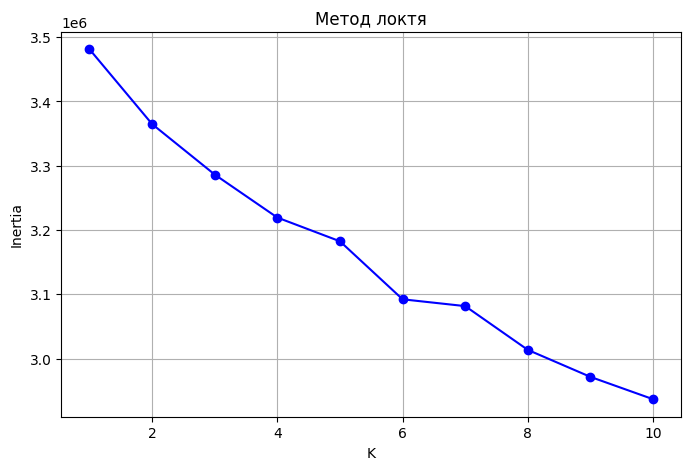

In [25]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Метод локтя')
plt.grid(True)
plt.show()

In [26]:
df_clustered = df.copy()
df_clustered['Cluster'] = labels

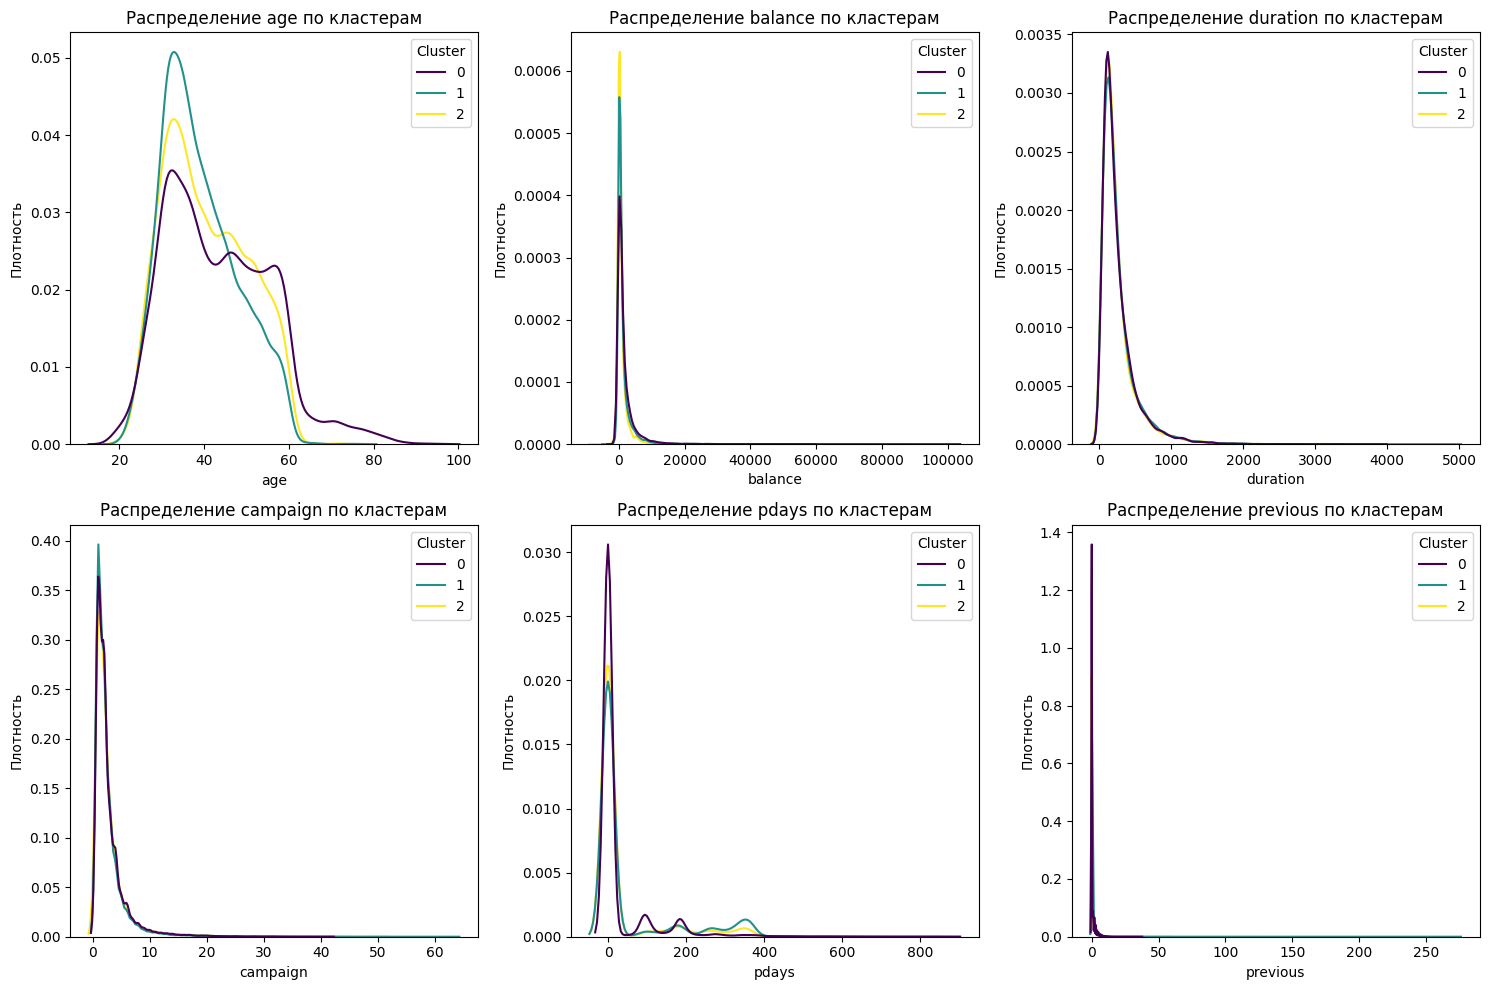

In [27]:
numerical_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.kdeplot(data=df_clustered, x=feature, hue='Cluster', fill=False, common_norm=False, palette='viridis')
    plt.title(f'Распределение {feature} по кластерам')
    plt.xlabel(feature)
    plt.ylabel('Плотность')
plt.tight_layout()
plt.show()

In [28]:
dbscan = DBSCAN(eps=1.0, min_samples=20)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Количество кластеров: {n_clusters}")
print(f"Количество шумовых точек: {n_noise}")

unique, counts = np.unique(dbscan_labels, return_counts=True)

Количество кластеров: 27
Количество шумовых точек: 44466


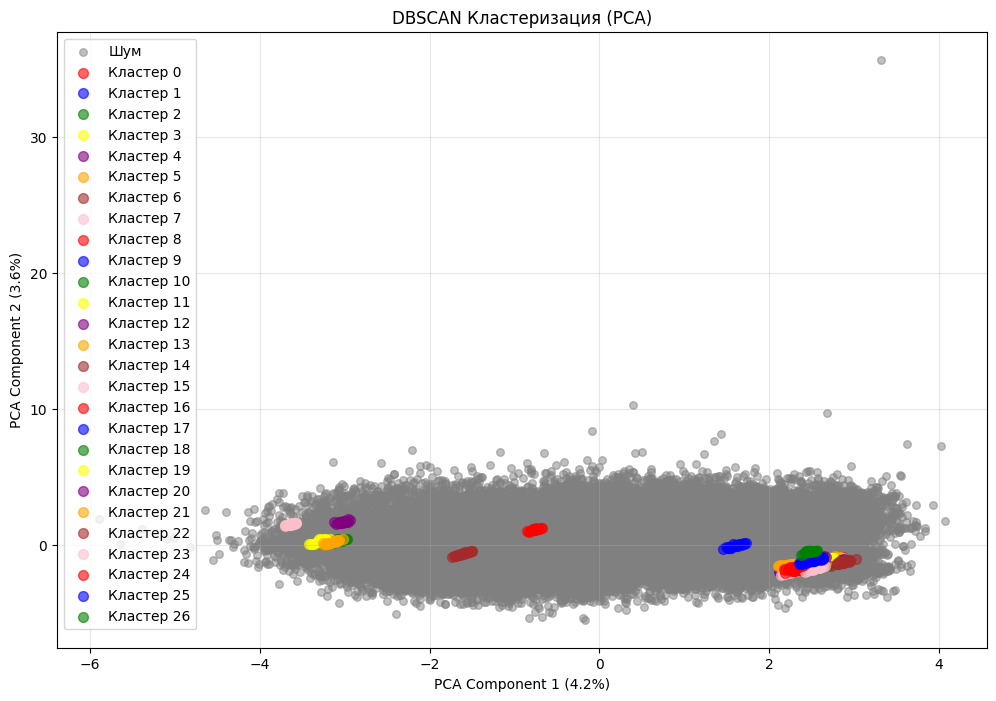

In [29]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))

plt.scatter(X_pca[dbscan_labels == -1, 0], X_pca[dbscan_labels == -1, 1],
           c='gray', label='Шум', alpha=0.5, s=30)

colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'brown', 'pink']
for i in range(n_clusters):
    plt.scatter(X_pca[dbscan_labels == i, 0], X_pca[dbscan_labels == i, 1],
               c=colors[i % len(colors)], label=f'Кластер {i}', alpha=0.6, s=50)

plt.title('DBSCAN Кластеризация (PCA)')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_15748/1265430378.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


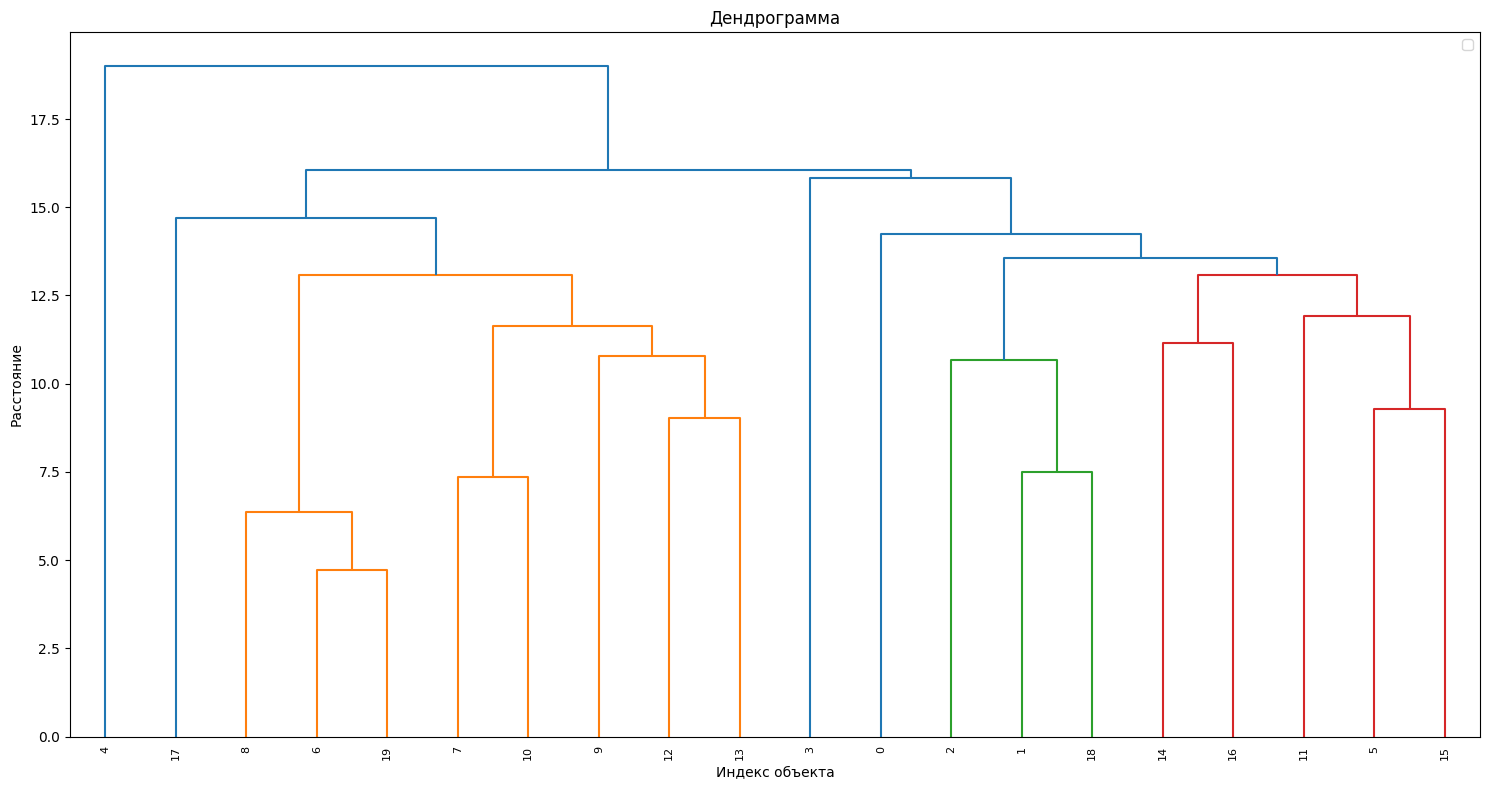

In [32]:
sample_size = min(20, len(X_scaled))
indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[indices]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(Z, leaf_rotation=90, leaf_font_size=8)
plt.title('Дендрограмма')
plt.xlabel('Индекс объекта')
plt.ylabel('Расстояние')
plt.legend()
plt.tight_layout()
plt.show()